# Yolo Tutorial - Solar Physics Data

## 1. Prerrequisites

In [11]:
import os
import re
import requests
from zipfile import ZipFile
from io import BytesIO
from pathlib import Path

from shapely import wkt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import re
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split

## 2. Fetch the data

Let's request a sample from the [SDO Dataverse](https://dataverse.harvard.edu/dataverse/lsdo) database. This database contains SDO 4096x4096 observations with boundaing boxes on structures such as Coronal Holes, Active regions, etc., being perfect to use for YOLO.

In [ ]:
data_folder = Path("../data/sdo_dataverse")
sample_folder = data_folder / "sample"

if not data_folder.exists():
    # Database url and query endpoints
    SERVER_URL = "https://dataverse.harvard.edu"
    PERSISTENT_ID = "doi:10.7910/DVN/8XRUDT"

    url = f"{SERVER_URL}/api/access/dataset/:persistentId/?persistentId={PERSISTENT_ID}"

    # Request data from the URL
    r = requests.get(url)
    r.raise_for_status()   # check e.g. for 403 if restricted

    # Open ZIP from bytes in memory and extract
    with ZipFile(BytesIO(r.content)) as zf:
        zf.extractall(data_folder)  # target directory (created if needed)


    # Extract the Zip sample folders 
    def extract_and_delete(zip_path, extract_folder):
        with ZipFile(zip_path) as zf:
            zf.extractall(extract_folder)
        
        os.remove(zip_path)
    
    inside_sample_folders = ["LSDO_Sample_Images", "LSDO_Sample_Parameters"]

    for s in inside_sample_folders:
        extract_and_delete(zip_path = sample_folder/(s+".zip"), 
                        extract_folder = sample_folder/s)
else:
    print(f"folder {str(data_folder)} already exists")

folder ../data already exists


## 3. Visualization

Let's visualize the bounding boxes from one of the samples we downloaded. Not only we will have to upload the image data but also the info from the bounding boxes stored in the `.txt` files. The .txt files correspond to

- `sample_event_file_name.txt`: Stores the name and path of each JPEG2000 sample file.
- `sample_event_recors.txt`: Stores the event type information with the corresponding bounding box and the sample it corresponds to. Many events could correspond to one same sample.

In [13]:
IMG_BASE = sample_folder / "LSDO_Sample_Images"

events = pd.read_csv(
    sample_folder / "sample_event_records.txt", sep="\t"
)

files = pd.read_csv(
    sample_folder / "sample_event_file_name_paths.txt",
    sep="\t", header=None, names=["filename", "rel_path"]
).set_index("filename")

# File paths to the samples
file_paths = files["rel_path"]


In [14]:
events.head(1)

,id,event_type,start_time,end_time,channel,bbox,sfilename,mfilename,efilename,frm_name
0,AR_SPoCA_20130101_072037_20130101T070400_4,AR,2013-01-01T03:04:00,2013-01-01T07:04:00,171,"POLYGON ((728 1989, 907 1989, 907 1799, 728 17...",2013_01_01__03_03_59_34__SDO_AIA_AIA_171,2013_01_01__05_03_59_34__SDO_AIA_AIA_171,2013_01_01__07_04_11_34__SDO_AIA_AIA_171,SPoCA


In [15]:
file_paths.head()

filename
2013_01_01__00_03_42_84__SDO_AIA_AIA_193    ./SDO/AIA/193/2013/01/01/2013_01_01__00_03_42_...
2013_01_01__04_03_42_84__SDO_AIA_AIA_193    ./SDO/AIA/193/2013/01/01/2013_01_01__04_03_42_...
2013_01_01__06_03_42_84__SDO_AIA_AIA_193    ./SDO/AIA/193/2013/01/01/2013_01_01__06_03_42_...
2013_01_01__02_03_42_84__SDO_AIA_AIA_193    ./SDO/AIA/193/2013/01/01/2013_01_01__02_03_42_...
2013_01_01__08_03_42_84__SDO_AIA_AIA_193    ./SDO/AIA/193/2013/01/01/2013_01_01__08_03_42_...
Name: rel_path, dtype: object

Now that we have the file paths and events data uploaded, we'll need to translate the `POLYGON()` coordinates to readable series of $(x,y)$ points to plot the bounding boxes on the corresponding SDO snapshot.

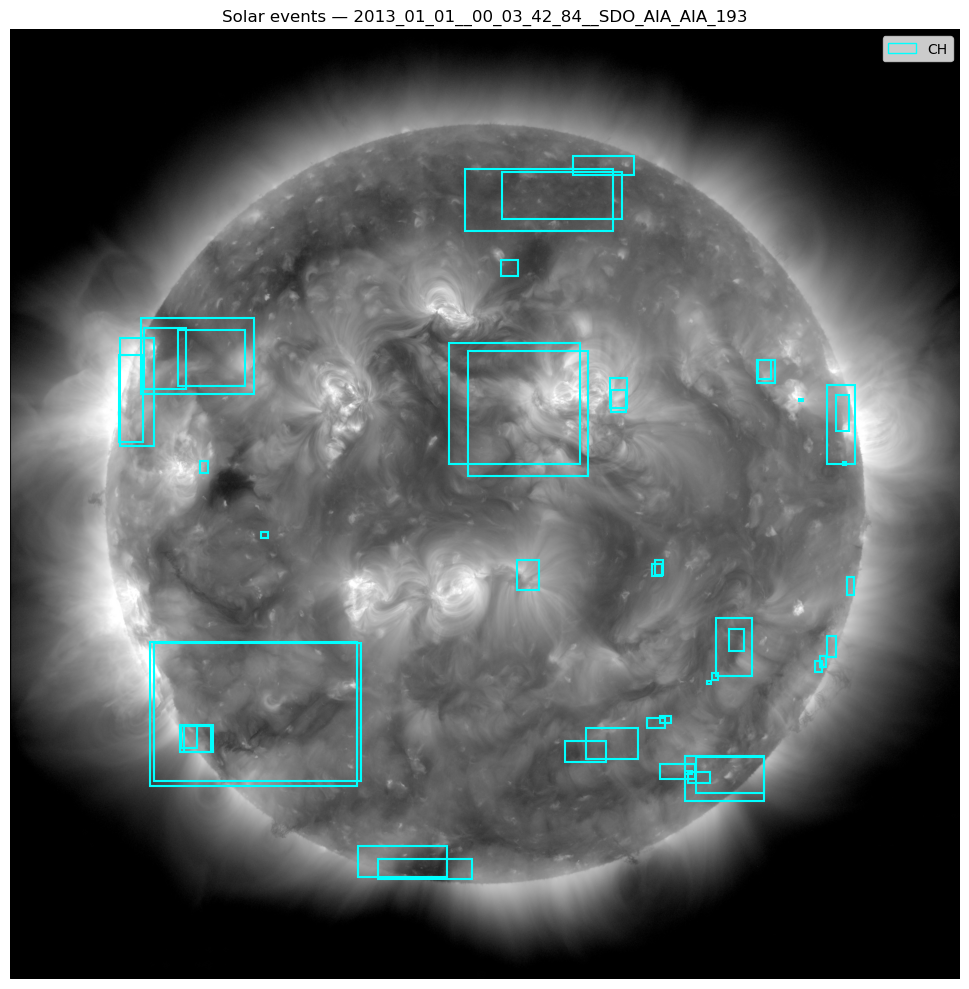

In [16]:
def parse_bbox(wkt_str):
    geom = wkt.loads(wkt_str)
    xmin, ymin, xmax, ymax = geom.bounds
    return xmin, ymin, xmax - xmin, ymax - ymin


# --- Choose an image to display (pick any mfilename) ---
target_file = files.index[0]
img_path = IMG_BASE / file_paths[target_file].lstrip("./")
image = np.array(Image.open(img_path))

# --- Get all events whose mfilename matches ---
subset = events[events["mfilename"] == target_file].copy()

# --- Color per event type ---
colors = {"AR": "red", "FL": "yellow", "CH": "cyan"}

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(image, cmap="gray", origin="upper")

for _, row in subset.iterrows():
    xmin, ymin, w, h = parse_bbox(row["bbox"])
    color = colors.get(row["event_type"], "white")
    rect = patches.Rectangle(
        (xmin, ymin), w, h,
        linewidth=1.5, edgecolor=color, facecolor="none", label=row["event_type"]
    )
    ax.add_patch(rect)

# Deduplicate legend entries
handles = {t: patches.Patch(edgecolor=c, facecolor="none", label=t)
           for t, c in colors.items() if t in subset["event_type"].values}
ax.legend(handles=handles.values(), loc="upper right", fontsize=10)
ax.set_title(f"Solar events — {target_file}")
ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Training and Validation datasets

Let's separate the image-label information into `train` (training) and `val` (validation) datasets. The JPEG200 data has to been converted to PNG since YOLO is only able to process RGB image. Since SDO images are just grayscale (one channel), we will copy the same channel three times to create the three "RGB" channels.

In [17]:
OUT = Path("../yolo_dataset").resolve()  # resolve once, use everywhere
CLASS_MAP = {"AR": 0, "FL": 1, "CH": 2}
IMG_SIZE = 4096

def parse_bbox_yolo(wkt_str):
    geom = wkt.loads(wkt_str)
    xmin, ymin, xmax, ymax = geom.bounds
    cx = (xmin + xmax) / 2 / IMG_SIZE
    cy = (ymin + ymax) / 2 / IMG_SIZE
    w  = (xmax - xmin) / IMG_SIZE
    h  = (ymax - ymin) / IMG_SIZE
    return cx, cy, w, h

In [18]:
# Group events by image
grouped = events.groupby("mfilename")
all_filenames = [f for f in grouped.groups if f in file_paths.index]

# Train/val split
train_files, val_files = train_test_split(all_filenames, test_size=0.2, random_state=42)

for split, filenames in [("train", train_files), ("val", val_files)]:
    (OUT / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUT / "labels" / split).mkdir(parents=True, exist_ok=True)

    for fname in filenames:
        # Convert JP2 → PNG (grayscale → RGB)
        jp2_path = IMG_BASE / file_paths[fname].lstrip("./")
        img = Image.open(jp2_path).convert("RGB")
        img.save(OUT / "images" / split / f"{fname}.png")

        # Write YOLO label file
        label_lines = []
        for _, row in grouped.get_group(fname).iterrows():
            cls = CLASS_MAP.get(row["event_type"])
            if cls is None:
                continue
            cx, cy, w, h = parse_bbox_yolo(row["bbox"])
            label_lines.append(f"{cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

        (OUT / "labels" / split / f"{fname}.txt").write_text("\n".join(label_lines))

print("Done. Train:", len(train_files), "Val:", len(val_files))

Done. Train: 101 Val: 26


## 5. Fine-tuning YOLO

In [19]:
# YAML already uses absolute path because OUT is resolved
yaml_content = f"""
path: {OUT}
train: images/train
val: images/val

nc: 3
names: ["AR", "FL", "CH"]
"""
(OUT / "sdo.yaml").write_text(yaml_content)


147

In [20]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")  # or yolo11s/m/l/x — larger = better but slower

model.train(
    data=OUT/"sdo.yaml",
    epochs=50,
    imgsz=1280,       # important — see note below
    batch=4,          # reduce if OOM; 4096px PNGs are heavy
    lr0=1e-4,         # lower LR for fine-tuning
    freeze=10,        # freeze first 10 backbone layers initially
    project="sdo_yolo",
    name="run1",
)


Ultralytics 8.4.41 🚀 Python-3.14.2 torch-2.10.0+cu128 CPU (Intel Core i5-8250U 1.60GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/juanessao/Documents/Proyectos/YoloProjects/Project1/yolo_dataset/sdo.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run1, nbs=64, nms=False, opset=None, optimize=Fa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b4a00ecad60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [28]:
model = YOLO("runs/detect/sdo_yolo/run1/weights/best.pt")
results = model.val(data="../yolo_dataset/sdo.yaml")
print(results.box.map50)  # mAP@50

# Predict on a single image
results = model.predict("../yolo_dataset/images/val/2013_01_01__01_02_47_34__SDO_AIA_AIA_171.png", imgsz=1280)
results[0].show()


Ultralytics 8.4.41 🚀 Python-3.14.2 torch-2.10.0+cu128 CPU (Intel Core i5-8250U 1.60GHz)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5257.9±1040.6 MB/s, size: 10844.6 KB)
val: Scanning /home/juanessao/Documents/Proyectos/YoloProjects/Project1/yolo_dataset/labels/val.cache... 26 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 26/26 9.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 10.2s/it 20.4s43.2s
                   all         26        215      0.223      0.213      0.185     0.0795
                    AR          3         17      0.373      0.529      0.494      0.215
                    FL         13         13     0.0948     0.0769     0.0445     0.0175
                    CH          5        185      0.203     0.0317     0.0174    0.00646
Speed: 8.0ms preprocess, 391.4ms inference, 0.0ms loss, 56.4ms postproces

In [30]:
results[0].show()

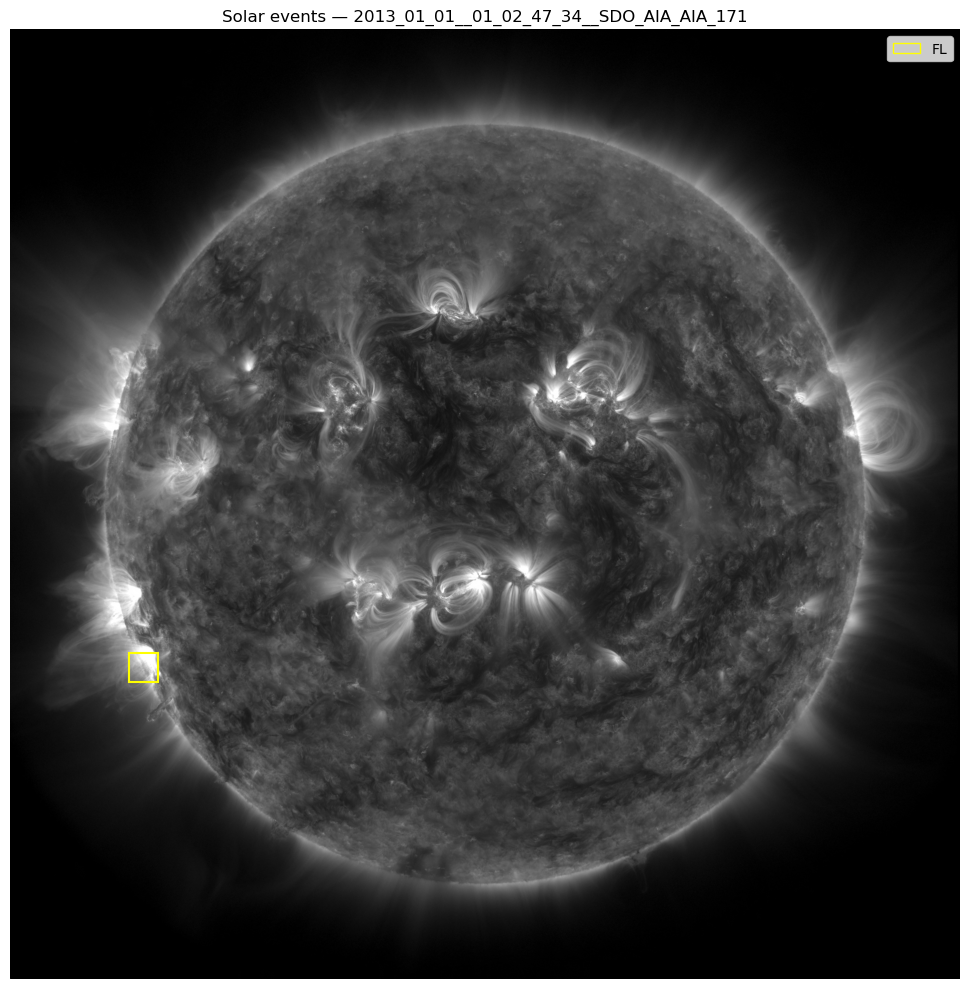

In [29]:
# --- Choose an image to display (pick any mfilename) ---
target_file = '2013_01_01__01_02_47_34__SDO_AIA_AIA_171'
img_path = IMG_BASE / file_paths[target_file].lstrip("./")
image = np.array(Image.open(img_path))

# --- Get all events whose mfilename matches ---
subset = events[events["mfilename"] == target_file].copy()

# --- Color per event type ---
colors = {"AR": "red", "FL": "yellow", "CH": "cyan"}

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(image, cmap="gray", origin="upper")

for _, row in subset.iterrows():
    xmin, ymin, w, h = parse_bbox(row["bbox"])
    color = colors.get(row["event_type"], "white")
    rect = patches.Rectangle(
        (xmin, ymin), w, h,
        linewidth=1.5, edgecolor=color, facecolor="none", label=row["event_type"]
    )
    ax.add_patch(rect)

# Deduplicate legend entries
handles = {t: patches.Patch(edgecolor=c, facecolor="none", label=t)
           for t, c in colors.items() if t in subset["event_type"].values}
ax.legend(handles=handles.values(), loc="upper right", fontsize=10)
ax.set_title(f"Solar events — {target_file}")
ax.axis("off")
plt.tight_layout()
plt.show()